# CBB Head-to-Head Predictor — LostTo Pairwise Model (Symmetric & Stable)

This notebook builds a **head-to-head** model from `newPastCBB.csv` by using the `LostTo` column to create actual game-level training data. It trains a Decision Tree on **pairwise difference features** and exposes a symmetric prediction function with a same-team 50/50 guard.

**Key features**
- Reliable join: `LostTo` equals opponent `Team` (works with your CSVs)
- Imputation for missing stats
- Same-team queries return **exactly 50/50**
- Symmetric probabilities: averages `P(A beats B)` and `1 - P(B beats A)` so order doesn’t matter
- Name resolver for convenient string inputs


In [1]:
# Imports
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from difflib import get_close_matches

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Optional: persist model & features if you want to avoid retraining later
# from joblib import dump, load

PAST_PATH = "newPastCBB.csv"
CURRENT_PATH = "cbb25.csv"


In [2]:
# Load CSVs
past = pd.read_csv(PAST_PATH)
current = pd.read_csv(CURRENT_PATH)

# Drop common auto-index column if present
for df in (past, current):
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

print('Past shape:', past.shape)
print('Current shape:', current.shape)
display(past.head(5))
display(current.head(5))

Past shape: (1079, 30)
Current shape: (68, 24)


,Team,Conf,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,3P%D,3PR,3PRD,ADJ_T,WAB,Win%,Year,TeamText,matched_official_team,LostTo
0,2011_Ohio_St_,B10,37,34,126.010,91.811,0.97421,56.3200,48.3126,15.8700,...,34.0147,32.7171,34.6231,63.8246,11.710,0.918919,2011,Ohio St,Ohio St,2011_Kentucky
1,2011_Kansas,B12,38,35,120.940,91.060,0.96332,57.0100,44.5110,19.1111,...,29.8900,32.4179,34.6231,68.0480,10.220,0.921053,2011,Kansas,Kansas,2011_VCU
2,2011_Duke,ACC,37,32,120.650,91.580,0.96003,53.7170,44.5110,17.2290,...,32.4580,35.3113,24.5500,68.5380,9.330,0.864865,2011,Duke,Duke,2011_Arizona
3,2011_Texas,B12,36,28,115.521,90.020,0.94604,50.2108,42.5300,17.3310,...,29.5600,25.5324,26.1120,65.5157,5.413,0.777778,2011,Texas,Texas,2011_Arizona
4,2011_Kentucky,SEC,38,29,119.370,93.422,0.94375,52.3410,44.2900,16.1100,...,32.4580,32.4179,29.7720,64.8191,5.215,0.763158,2011,Kentucky,Kentucky,2011_Connecticut


,Team,Conf,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTR,FTRD,2P%,2P%D,3P%,3P%D,3PR,3PRD,ADJ_T,WAB
0,Houston,B12,34,30,124.89,88.010,0.98231,52.788,44.940,14.6250,...,27.2328,34.2216,47.8295,44.550,39.430,30.214,34.7285,43.4313,61.8360,11.52
1,Duke,ACC,34,31,128.52,91.340,0.98082,57.450,44.530,14.4190,...,32.9182,25.0170,57.9800,43.030,38.670,31.137,44.6580,38.3157,66.0272,9.55
2,Auburn,SEC,33,28,129.11,93.712,0.97563,55.725,46.011,13.4600,...,33.9152,38.7310,55.7330,46.829,35.966,29.890,40.8136,35.3600,68.3133,12.71
3,Florida,SEC,34,30,127.73,94.013,0.97144,55.037,45.360,15.0360,...,34.9121,32.5167,56.1290,46.317,35.673,29.450,43.7720,37.2119,69.9590,11.23
4,Alabama,SEC,33,25,127.64,96.428,0.96205,56.314,47.950,16.7149,...,39.3300,33.2187,59.7400,49.095,35.393,30.419,46.6340,34.6420,75.1100,10.14


## Build matchup dataset from `LostTo`
- Keep rows with a `LostTo` value (they represent games from the loser's perspective).
- Join to the opponent row where `OppTeam == Team` in the same CSV.
- Compute **difference features**: `diff_stat = stat_team − stat_opp` for all numeric stats (except `Result`).
- Label (team vs opp) as `0` because this team lost; create a **flipped** copy (opp vs team) labeled `1`.

In [3]:
# Identify numeric columns and choose features (exclude 'Result' which is an outcome)
numeric_cols = [c for c in past.columns if pd.api.types.is_numeric_dtype(past[c])]
feature_stats = [c for c in numeric_cols if c != 'Result']

# Sanity check for LostTo
if 'LostTo' not in past.columns:
    raise ValueError("Expected 'LostTo' column in past data.")

# Only games with an opponent
games = past.dropna(subset=['LostTo']).copy()

# Opponent lookup within the same CSV
opp_table = past[['Team'] + feature_stats].rename(columns={'Team': 'OppTeam'})

# Simple robust merge: LostTo equals opponent Team
games = games.merge(opp_table, left_on='LostTo', right_on='OppTeam', how='inner', suffixes=('', '_opp'))

print('Matched games:', games.shape[0])
if games.shape[0] == 0:
    raise RuntimeError("No games matched between LostTo and Team. Check LostTo formatting in newPastCBB.csv.")

# Pairwise (team - opponent) features
pair_features = []
for c in feature_stats:
    if c + '_opp' in games.columns:
        fname = f'diff_{c}'
        games[fname] = games[c] - games[c + '_opp']
        pair_features.append(fname)

print('Pairwise feature count:', len(pair_features))
if len(pair_features) == 0:
    raise RuntimeError("No pairwise features were created. Verify numeric columns in newPastCBB.csv.")

# Labels: original direction (team lost to OppTeam) -> 0
games['label'] = 0

# Flipped direction where winner is first -> 1
flip = pd.DataFrame({
    'Team': games['OppTeam'],
    'OppTeam': games['Team'],
    'label': 1
})
for f in pair_features:
    flip[f] = -games[f]

pair_df = pd.concat([games[['Team','OppTeam','label'] + pair_features], flip], ignore_index=True)
print('Pairwise dataset shape:', pair_df.shape)
display(pair_df.head())

Matched games: 735
Pairwise feature count: 24
Pairwise dataset shape: (1470, 27)


,Team,OppTeam,label,diff_G,diff_W,diff_ADJOE,diff_ADJDE,diff_BARTHAG,diff_EFG_O,diff_EFG_D,...,diff_2P%,diff_2P%D,diff_3P%,diff_3P%D,diff_3PR,diff_3PRD,diff_ADJ_T,diff_WAB,diff_Win%,diff_Year
0,2011_Ohio_St_,2011_Kentucky,0,-1,5,6.640,-1.611,0.030460,3.9790,4.0226,...,4.0997,4.4530,2.5200,1.5567,0.2992,4.8511,-0.9945,6.495,0.155761,0
1,2011_Kansas,2011_VCU,0,-2,7,8.300,-8.850,0.163759,5.8380,-4.7062,...,8.7937,-4.1785,1.1690,-3.7218,-8.8041,4.5451,2.9306,12.199,0.221053,0
2,2011_Duke,2011_Arizona,0,-1,2,1.870,-6.487,0.059610,-0.3950,-4.1026,...,1.4760,-7.3115,-2.3450,3.1280,-0.8767,-3.7900,3.6190,4.714,0.075391,0
3,2011_Texas,2011_Arizona,0,-2,-2,-3.259,-8.047,0.045620,-3.9012,-6.0836,...,-2.9242,-8.4775,-2.1540,0.2300,-10.6556,-2.2280,0.5967,0.797,-0.011696,0
4,2011_Kentucky,2011_Connecticut,0,-3,-3,3.552,-0.201,0.023637,4.1199,-0.2210,...,1.0947,0.0000,6.8666,-0.3140,3.0922,-2.4435,0.5962,-1.595,-0.017330,0


## Train Decision Tree on pairwise differences
Uses median imputation for any missing features. We show 5-fold CV if possible, then fit the final model.

In [4]:
# Features and labels
X_cols = [c for c in pair_df.columns if c.startswith('diff_')]
X = pair_df[X_cols].copy()
y = pair_df['label'].astype(int).values

# Pipeline: impute missing diffs + Decision Tree
pre = ColumnTransformer([('num', SimpleImputer(strategy='median'), X_cols)])
model = Pipeline([
    ('pre', pre),
    ('clf', DecisionTreeClassifier(random_state=42, max_depth=6, min_samples_leaf=25))
])

# Cross-validation (guarded)
try:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print('5-fold CV accuracy:', round(scores.mean(), 3), '+/-', round(scores.std(), 3))
except Exception as e:
    print('CV skipped:', e)

# Fit final model
model.fit(X, y)
FEATURE_LIST = X_cols
print('Training complete. Features used:', len(FEATURE_LIST))

5-fold CV accuracy: 0.873 +/- 0.019
Training complete. Features used: 24


## Helper: resolve team names flexibly
Allows you to type team names as strings (case/spacing insensitive, supports partials and minor typos).

In [5]:
def _normalize_name(s: str) -> str:
    return re.sub(r'[_\s]+', ' ', str(s).strip().lower())

def resolve_team(name: str, df: pd.DataFrame) -> str:
    if 'Team' not in df.columns:
        raise ValueError("DataFrame must include a 'Team' column.")
    typed = name.strip()
    teams = df['Team'].astype(str).tolist()

    # exact
    if typed in teams:
        return typed
    # case-insensitive
    lower_map = {t.lower(): t for t in teams}
    if typed.lower() in lower_map:
        return lower_map[typed.lower()]
    # normalized
    norm_map = {_normalize_name(t): t for t in teams}
    n = _normalize_name(typed)
    if n in norm_map:
        return norm_map[n]
    # contains
    cand = [t for t in teams if n in _normalize_name(t)]
    if len(cand) == 1:
        return cand[0]
    if len(cand) > 1:
        print("Multiple matches found for", repr(typed), "->", cand[:10])
        from difflib import get_close_matches
        best = get_close_matches(typed, cand, n=1)
        if best:
            return best[0]
    # fuzzy over all
    best = get_close_matches(typed, teams, n=1)
    if best:
        print(f"Did you mean '{best[0]}'? Using that.")
        return best[0]
    raise ValueError(f"Team '{name}' not found in current['Team'].")

## Prediction utilities (symmetric + same-team 50/50)
- `_build_diff_vector` sets a diff to **0.0** when **both teams** lack that stat (neutral), otherwise NaN for imputation.
- `predict_match_winner_pairwise` returns 50/50 for same-team, and averages both directions for symmetry.

In [6]:
def _build_diff_vector(current_df: pd.DataFrame, team_a: str, team_b: str, feature_list):
    if 'Team' not in current_df.columns:
        raise ValueError("current_df must include a 'Team' column.")
    if team_a not in set(current_df['Team']) or team_b not in set(current_df['Team']):
        raise ValueError("Both team names must exist in current_df['Team'].")
    A = current_df[current_df['Team'] == team_a].iloc[0]
    B = current_df[current_df['Team'] == team_b].iloc[0]

    row = {}
    for f in feature_list:
        base = f.replace('diff_', '')
        a_has = base in A.index
        b_has = base in B.index
        if a_has and b_has:
            try:
                row[f] = float(A[base]) - float(B[base])
            except Exception:
                row[f] = np.nan
        elif (not a_has) and (not b_has):
            row[f] = 0.0   # neutral if both missing
        else:
            row[f] = np.nan  # one missing → imputer handles
    return pd.DataFrame([row])

def predict_match_winner_pairwise(current_df: pd.DataFrame, team_a: str, team_b: str, fitted_model, feature_list):
    # same-team → 50/50 by design
    if team_a == team_b:
        return {'winner': team_a, 'prob_A_wins': 0.5, 'prob_B_wins': 0.5}

    X_ab = _build_diff_vector(current_df, team_a, team_b, feature_list)
    p_ab = float(fitted_model.predict_proba(X_ab)[0][1])  # P(A beats B)

    X_ba = _build_diff_vector(current_df, team_b, team_a, feature_list)
    p_ba = float(fitted_model.predict_proba(X_ba)[0][1])  # P(B beats A)

    # Symmetrize
    pA = 0.5 * (p_ab + (1.0 - p_ba))
    pB = 1.0 - pA
    winner = team_a if pA >= 0.5 else team_b
    return {'winner': winner, 'prob_A_wins': pA, 'prob_B_wins': pB}

## Name-based demo (edit the strings)
Type two team names (roughly) and the resolver will match them from `current['Team']`. Same-team returns 50/50.

In [81]:


# <<< EDIT THESE >>> (strings)
TEAM_A_NAME = "Houston"
TEAM_B_NAME = "Florida"

TEAM_A = resolve_team(TEAM_A_NAME, current)
TEAM_B = resolve_team(TEAM_B_NAME, current)

print('TEAM_A =', TEAM_A)
print('TEAM_B =', TEAM_B)

res = predict_match_winner_pairwise(current, TEAM_A, TEAM_B, model, FEATURE_LIST)
print('\nPredicted winner:', res['winner'])
print('P(TEAM_A wins):', round(res['prob_A_wins'], 3))
print('P(TEAM_B wins):', round(res['prob_B_wins'], 3))

TEAM_A = Houston
TEAM_B = Florida

Predicted winner: Houston
P(TEAM_A wins): 0.647
P(TEAM_B wins): 0.353


Accuracy: 0.873
                      precision    recall  f1-score   support

First team loses (0)       0.87      0.88      0.87       735
 First team wins (1)       0.88      0.86      0.87       735

            accuracy                           0.87      1470
           macro avg       0.87      0.87      0.87      1470
        weighted avg       0.87      0.87      0.87      1470



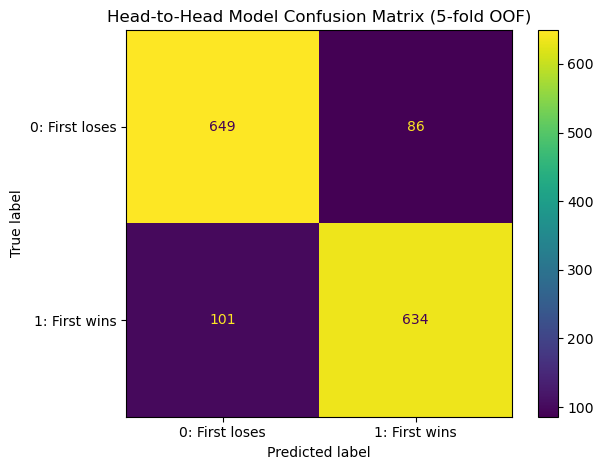

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')

# confusion matrix + metrics
cm = confusion_matrix(y, y_pred, labels=[0, 1])
acc = accuracy_score(y, y_pred)
print("Accuracy:", round(acc, 3))
print(classification_report(y, y_pred, target_names=['First team loses (0)', 'First team wins (1)']))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0: First loses', '1: First wins'])
fig, ax = plt.subplots()
disp.plot(ax=ax, values_format='d')
plt.title("Head-to-Head Model Confusion Matrix (5-fold OOF)")
plt.tight_layout()
plt.show()

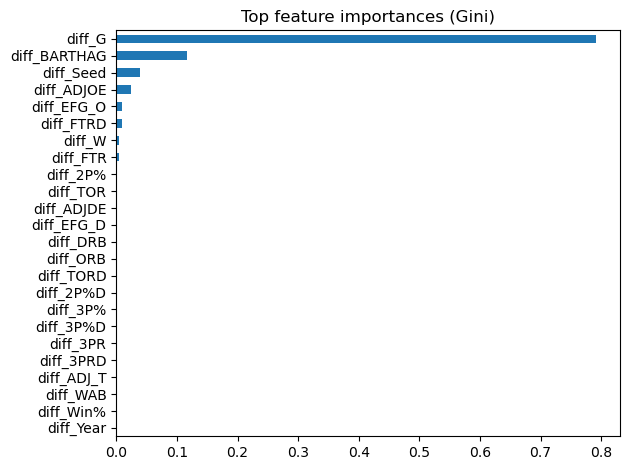

In [9]:
imp = model.named_steps['clf'].feature_importances_
fi = pd.Series(imp, index=FEATURE_LIST).sort_values(ascending=False).head(25)
fi.plot(kind='barh'); plt.gca().invert_yaxis()
plt.title("Top feature importances (Gini)"); plt.tight_layout(); plt.show()